[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/12_hessian_jacobian_curvature/first_principles.ipynb)

# Module 12 — Hessian, Jacobian, and Curvature

## 1. Why This Module Exists

In one variable, $f'(x)$ gives the tangent line and $f''(x)$ decides whether the graph curves up or
down. In $n$ variables neither object is a number any more, and two different matrices take over.

**Vector-valued maps.** For $f : \Omega \subseteq \mathbb{R}^n \to \mathbb{R}^m$ the best local linear
model of $f$ near $x_0$ is a matrix, the Jacobian $J_f(x_0) \in \mathbb{R}^{m \times n}$. When
$m = n$ its determinant is the factor by which $f$ scales volume near $x_0$. That single number is what
makes the change-of-variables formula for multiple integrals work, and it is why a normalising flow in
machine learning can report an exact log-density.

**Scalar fields.** For $f : \Omega \subseteq \mathbb{R}^n \to \mathbb{R}$ the gradient $\nabla f(x)$
points uphill, but it says nothing about the shape of the surface at a point where it vanishes. A bowl,
a dome, a flat plateau and a mountain pass all have $\nabla f = \mathbf{0}$. Distinguishing them needs
the matrix of second partials, the Hessian $\nabla^2 f(x) \in \mathbb{R}^{n \times n}$, and specifically
needs the signs of its eigenvalues.

**Why this matters downstream.** Every optimisation guarantee in this curriculum is a statement about
Hessian eigenvalues: strong convexity is $\nabla^2 f \succeq \mu I$, smoothness is
$\nabla^2 f \preceq L I$, the gradient-descent rate is governed by
$\kappa = \lambda_{\max}/\lambda_{\min}$, and Newton's method converges quadratically exactly because
it uses $\nabla^2 f$ rather than approximating it by a multiple of the identity. This module builds all
of that from the definition of a partial derivative.

## 2. Intuition

Let $x_0$ be a **critical point**, $\nabla f(x_0) = \mathbf{0}$. Then the leading behaviour of $f$ near
$x_0$ is the quadratic form built from $H = \nabla^2 f(x_0)$:

$$
f(x_0 + h) - f(x_0) \approx \tfrac{1}{2} h^\top H h .
$$

Because $H$ is symmetric (Theorem 4.1) the spectral theorem supplies an orthonormal eigenbasis
$u_1, \ldots, u_n$ with $H u_i = \lambda_i u_i$. Writing $h = \sum_i c_i u_i$ turns the quadratic form
into a sum of decoupled one-dimensional parabolas:

$$
\tfrac{1}{2} h^\top H h = \tfrac{1}{2} \sum_{i=1}^{n} \lambda_i c_i^2 .
$$

So the surface is a parabola of curvature $\lambda_i$ along each eigenvector, and nothing else. Three
cases exhaust the non-degenerate possibilities:

- every $\lambda_i \gt 0$: every parabola opens upward, so $x_0$ sits at the bottom of a bowl;
- every $\lambda_i \lt 0$: every parabola opens downward, so $x_0$ sits at the top of a dome;
- some $\lambda_i \gt 0$ and some $\lambda_j \lt 0$: the surface rises along $u_i$ and falls along
  $u_j$, a saddle.

If some $\lambda_i = 0$ the quadratic term is blind along $u_i$ and higher-order terms decide; that is
the inconclusive case, not a fourth verdict.

The same eigen-picture explains why plain gradient descent struggles. The level sets of the quadratic
model are ellipses with semi-axes proportional to $\lambda_i^{-1/2}$. When
$\kappa = \lambda_{\max}/\lambda_{\min}$ is large those ellipses are long thin valleys, the negative
gradient points almost across the valley rather than along it, and the iterates zig-zag.

Figure 1 draws the three cases as contour plots of $\tfrac{1}{2} h^\top H h$ with the eigenvectors of
$H$ overlaid, so the decoupled parabolas of the previous cell are visible as the principal axes of the
level sets.

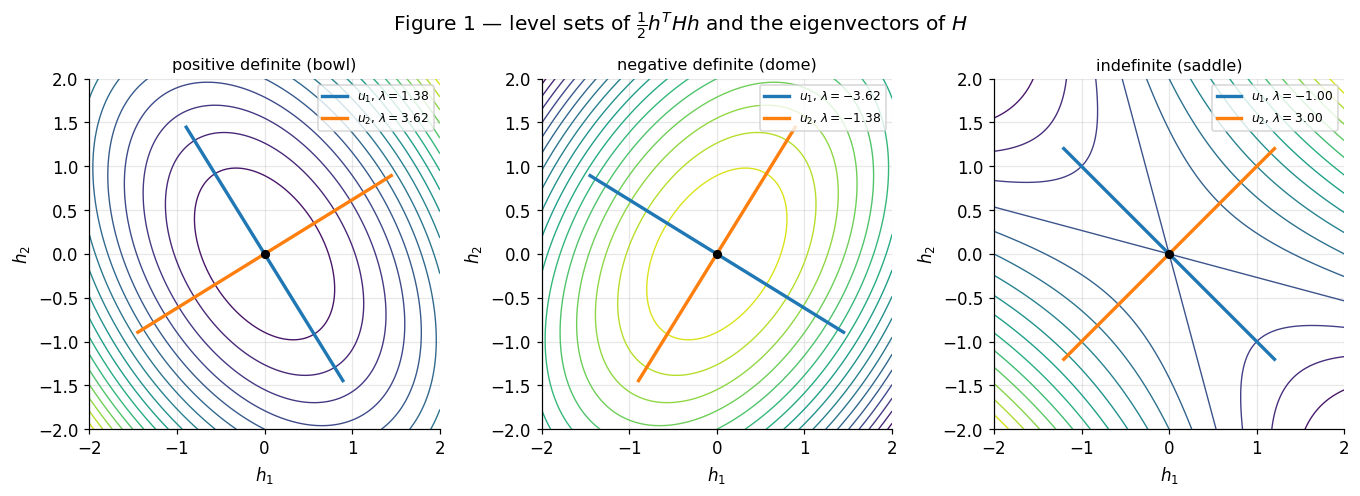

positive definite (bowl)     eigenvalues = [1.382 3.618]
negative definite (dome)     eigenvalues = [-3.618 -1.382]
indefinite (saddle)          eigenvalues = [-1.  3.]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)


def quad_form_grid(H, lim=2.0, n=241):
    """Evaluate q(h) = 0.5 h^T H h on a square grid; return (X, Y, Q)."""
    t = np.linspace(-lim, lim, n)
    X, Y = np.meshgrid(t, t)
    Q = 0.5 * (H[0, 0] * X**2 + 2.0 * H[0, 1] * X * Y + H[1, 1] * Y**2)
    return X, Y, Q


cases = {
    "positive definite (bowl)": np.array([[3.0, 1.0], [1.0, 2.0]]),
    "negative definite (dome)": np.array([[-3.0, 1.0], [1.0, -2.0]]),
    "indefinite (saddle)": np.array([[1.0, 2.0], [2.0, 1.0]]),
}

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.4))
for ax, (name, H) in zip(axes, cases.items()):
    X, Y, Q = quad_form_grid(H)
    lam, U = np.linalg.eigh(H)
    ax.contour(X, Y, Q, levels=18, linewidths=0.9)
    for k in range(2):
        v = 1.7 * U[:, k]
        ax.plot([-v[0], v[0]], [-v[1], v[1]], lw=2.2,
                label=f"$u_{k+1}$, $\\lambda={lam[k]:.2f}$")
    ax.plot(0, 0, "ko", ms=5)
    ax.set_aspect("equal")
    ax.set_title(name, fontsize=10.5)
    ax.set_xlabel("$h_1$")
    ax.set_ylabel("$h_2$")
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Figure 1 — level sets of $\\frac{1}{2}h^{T}Hh$ and the eigenvectors of $H$")
fig.tight_layout()
plt.show()

for name, H in cases.items():
    print(f"{name:28s} eigenvalues = {np.linalg.eigvalsh(H)}")

The principal axes of every contour ellipse or hyperbola coincide with the eigenvectors of $H$, and the
sign pattern of the eigenvalues printed underneath matches the verdict in the panel title. The middle
panel is the first panel reflected through $f \mapsto -f$, which is exactly why the negative-definite
case needs no separate proof.

## 3. Definitions

Throughout, $\Omega \subseteq \mathbb{R}^n$ is open, $\lVert \cdot \rVert$ is the Euclidean norm on
vectors and the induced operator norm on matrices, and $e_1, \ldots, e_n$ is the standard basis.

### Definition 3.1 (Jacobian matrix and Jacobian determinant)

Let $f : \Omega \to \mathbb{R}^m$ with components $f = (f_1, \ldots, f_m)^\top$. If every partial
derivative $\partial f_i / \partial x_j$ exists at $x \in \Omega$, the **Jacobian matrix** of $f$ at $x$
is the $m \times n$ matrix

$$
J_f(x) = \begin{bmatrix}
\dfrac{\partial f_1}{\partial x_1} & \cdots & \dfrac{\partial f_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\dfrac{\partial f_m}{\partial x_1} & \cdots & \dfrac{\partial f_m}{\partial x_n}
\end{bmatrix},
\qquad (J_f(x))_{ij} = \frac{\partial f_i}{\partial x_j}(x).
$$

Its $i$-th row is $\nabla f_i(x)^\top$. When $m = n$ the scalar $\det J_f(x)$ is the **Jacobian
determinant**. When $m = 1$, $J_f = (\nabla f)^\top$.

### Definition 3.2 (Hessian matrix)

Let $f : \Omega \to \mathbb{R}$ have all second-order partial derivatives at $x$. The **Hessian** is the
$n \times n$ matrix

$$
\nabla^2 f(x), \qquad (\nabla^2 f(x))_{ij} = \frac{\partial^2 f}{\partial x_i \, \partial x_j}(x).
$$

Equivalently $\nabla^2 f = J_{\nabla f}$: the Hessian is the Jacobian of the gradient map. In this
notebook $H$ is used only as a local abbreviation for $\nabla^2 f$ evaluated at a point named in the
same cell.

### Definition 3.3 (definiteness)

A symmetric $A \in \mathbb{R}^{n \times n}$ is **positive definite**, written $A \succ 0$, if
$h^\top A h \gt 0$ for every $h \ne \mathbf{0}$; **positive semidefinite**, $A \succeq 0$, if
$h^\top A h \ge 0$ for every $h$; **negative (semi)definite** if $-A$ is positive (semi)definite; and
**indefinite** if $h^\top A h$ takes both signs. The **leading principal minor** $\Delta_k$ is the
determinant of the top-left $k \times k$ submatrix $A_{1:k,\,1:k}$.

### Definition 3.4 (Rayleigh quotient and condition number)

For symmetric $A \in \mathbb{R}^{n \times n}$ and $x \ne \mathbf{0}$ the **Rayleigh quotient** is

$$
R_A(x) = \frac{x^\top A x}{x^\top x}.
$$

Eigenvalues are indexed in **descending** order, $\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_n$,
and written $\lambda_{\max} = \lambda_1$, $\lambda_{\min} = \lambda_n$. For $A \succ 0$ the **spectral
condition number** is $\kappa(A) = \lambda_{\max}/\lambda_{\min} \ge 1$.

### Definition 3.5 (critical point)

A point $x_0 \in \Omega$ with $\nabla f(x_0) = \mathbf{0}$ is a **critical point** of $f$. It is a
**strict local minimum** if $f(x_0 + h) \gt f(x_0)$ for all $h \ne \mathbf{0}$ small enough, a **strict
local maximum** if the reverse inequality holds, and a **saddle point** if every neighbourhood of $x_0$
contains points where $f$ is larger and points where $f$ is smaller than $f(x_0)$.

## 4. Main Results

### Theorem 4.1 (Schwarz — symmetry of mixed partials)

Let $f : \Omega \to \mathbb{R}$, let $x_0 \in \Omega$, and fix indices $i \ne j$. If
$\partial^2 f / \partial x_i \partial x_j$ and $\partial^2 f / \partial x_j \partial x_i$ exist on a
neighbourhood of $x_0$ and are continuous at $x_0$, then

$$
\frac{\partial^2 f}{\partial x_i \, \partial x_j}(x_0)
= \frac{\partial^2 f}{\partial x_j \, \partial x_i}(x_0).
$$

Consequently $\nabla^2 f(x_0)$ is symmetric for every $f \in C^2(\Omega)$.

*Existence on a neighbourhood* is needed because the proof applies the mean value theorem on a whole
rectangle around $x_0$, not just at $x_0$. *Continuity at $x_0$* is needed because the proof produces
the two mixed partials at two different unknown interior points and can only identify their limits if
the functions are continuous there; Section 7 exhibits a function with both mixed partials existing
everywhere, discontinuous at the origin, and unequal there.

### Theorem 4.2 (second-order Taylor expansion with mean-value remainder)

Let $f \in C^2(\Omega)$ with $\Omega$ open and convex, and let $x, x + h \in \Omega$. Then there exists
$\theta \in (0,1)$ with

$$
f(x + h) = f(x) + \nabla f(x)^\top h + \tfrac{1}{2}\, h^\top \nabla^2 f(x + \theta h)\, h .
$$

If in addition $\nabla^2 f$ is $L$-Lipschitz on the segment, then

$$
\left\lvert f(x + h) - f(x) - \nabla f(x)^\top h - \tfrac{1}{2} h^\top \nabla^2 f(x) h \right\rvert
\le \tfrac{L}{6} \lVert h \rVert^3 .
$$

*Convexity of $\Omega$* is needed so the whole segment from $x$ to $x + h$ lies in the domain, which is
what lets the problem be reduced to one variable. *$C^2$* is needed so the reduced function
$g(t) = f(x + th)$ is twice continuously differentiable and the one-variable Taylor theorem applies.
*Lipschitz $\nabla^2 f$* is needed only for the cubic error bound; the mean-value form itself does not
use it.

### Theorem 4.3 (Rayleigh–Ritz)

Let $A \in \mathbb{R}^{n \times n}$ be symmetric with eigenvalues
$\lambda_{\max} = \lambda_1 \ge \cdots \ge \lambda_n = \lambda_{\min}$. Then for every
$x \ne \mathbf{0}$

$$
\lambda_{\min} \le \frac{x^\top A x}{x^\top x} \le \lambda_{\max},
$$

and both bounds are attained, at the corresponding eigenvectors. Equivalently
$\lambda_{\min} \lVert x \rVert^2 \le x^\top A x \le \lambda_{\max} \lVert x \rVert^2$ for all $x$.

*Symmetry* is needed twice: it makes the eigenvalues real, so the inequalities have meaning, and it
supplies the orthonormal eigenbasis in which the quadratic form separates. For a non-symmetric matrix
$R_A(x)$ depends only on the symmetric part $\tfrac{1}{2}(A + A^\top)$, so the statement is not lost,
only relocated.

### Theorem 4.4 (second-derivative test — the result this module is named for)

Let $f \in C^2(\Omega)$ and let $x_0 \in \Omega$ be a critical point, $\nabla f(x_0) = \mathbf{0}$.
Write $H = \nabla^2 f(x_0)$. Then:

1. $H \succ 0$ $\implies$ $x_0$ is a strict local minimum;
2. $H \prec 0$ $\implies$ $x_0$ is a strict local maximum;
3. $H$ indefinite $\implies$ $x_0$ is a saddle point;
4. if $H$ is semidefinite and singular, all three outcomes remain possible and the test is
   inconclusive.

*$C^2$* is needed so Theorem 4.2 supplies a remainder controlled by $\nabla^2 f$ at a nearby point and
so $\nabla^2 f$ is continuous, which is what upgrades definiteness at $x_0$ to definiteness on a
neighbourhood. *$\nabla f(x_0) = \mathbf{0}$* is needed to kill the linear term, which otherwise
dominates the quadratic one and makes the eigenvalues irrelevant. *Strict* definiteness is needed
because $\lambda_{\min} \gt 0$ is what gives the quadratic term room to beat the remainder; case 4 is
the price of losing it.

### Theorem 4.5 (Sylvester's criterion)

A symmetric $A \in \mathbb{R}^{n \times n}$ satisfies $A \succ 0$ if and only if all $n$ leading
principal minors are strictly positive: $\Delta_k \gt 0$ for $k = 1, \ldots, n$.

For $n = 2$ with $A = \begin{bmatrix} a & b \\ b & c \end{bmatrix}$ this reads $a \gt 0$ and
$ac - b^2 \gt 0$ for a minimum, $a \lt 0$ and $ac - b^2 \gt 0$ for a maximum, and $ac - b^2 \lt 0$ for a
saddle.

*Symmetry* is needed because the criterion is false without it. *Leading* minors are needed, not
arbitrary principal minors: $\operatorname{diag}(1, -1)$ has a positive non-leading minor. For positive
**semi**definiteness the analogous test requires **all** principal minors to be non-negative, not just
the leading ones — $\operatorname{diag}(0, -1)$ has $\Delta_1 = \Delta_2 = 0$ and is not $\succeq 0$.

### Theorem 4.6 (Jacobian determinant as a volume factor)

Let $f : \Omega \to \mathbb{R}^n$ be differentiable at $x$. Let $P_h$ be the parallelepiped spanned by
$h_1 e_1, \ldots, h_n e_n$ at $x$, of volume $\operatorname{vol}(P_h) = \prod_i \lvert h_i \rvert$. Then
the parallelepiped spanned by the images $J_f(x)(h_i e_i)$ has volume

$$
\lvert \det J_f(x) \rvert \operatorname{vol}(P_h),
$$

and if $f$ is $C^1$ with $\det J_f(x) \ne 0$, then
$\operatorname{vol}(f(x + P_h)) / \operatorname{vol}(P_h) \to \lvert \det J_f(x) \rvert$ as
$\max_i \lvert h_i \rvert \to 0$.

*Differentiability* is needed for the linear model to approximate $f$ to $o(\lVert h \rVert)$; mere
existence of partials is not enough. *$\det J_f(x) \ne 0$* is needed for the limit statement, since a
singular Jacobian collapses the image to lower dimension and the ratio degenerates. The **absolute
value** is needed because a negative determinant means an orientation reversal, and volumes are
non-negative.

### Theorem 4.7 (local quadratic convergence of Newton's method)

Let $f \in C^2$ near $x^\star$ with $\nabla f(x^\star) = \mathbf{0}$ and
$\nabla^2 f(x^\star) \succ 0$, and let $\nabla^2 f$ be $L$-Lipschitz on a ball $B(x^\star, r)$. Then
there are $\rho \in (0, r]$ and $M \gt 0$ such that for every $x^{(0)} \in B(x^\star, \rho)$ the
iteration

$$
x^{(k+1)} = x^{(k)} - \left[\nabla^2 f(x^{(k)})\right]^{-1} \nabla f(x^{(k)})
$$

stays in $B(x^\star, \rho)$ and satisfies
$\lVert x^{(k+1)} - x^\star \rVert \le \tfrac{ML}{2} \lVert x^{(k)} - x^\star \rVert^2$.

*$\nabla^2 f(x^\star) \succ 0$* is needed so the Hessian is invertible with a uniformly bounded inverse
near $x^\star$; without it the step is undefined or unbounded. *Lipschitz $\nabla^2 f$* is what turns
the error recursion quadratic — under $C^2$ alone the same argument gives superlinear but not
quadratic convergence. *Locality* is essential: Newton's method started far away can diverge or run to
a saddle, because a critical point of the quadratic model need not be its minimiser.

### Theorem 4.8 (softmax Jacobian and cross-entropy Hessian)

For $z \in \mathbb{R}^n$ let $S_i(z) = e^{z_i} / \sum_{k} e^{z_k}$, and for a fixed label
$y \in \lbrace 1, \ldots, n \rbrace$ let $\mathcal{L}(z) = -\ln S_y(z)$. Then

$$
J_S(z) = \operatorname{diag}(S) - S S^\top, \qquad
\nabla \mathcal{L}(z) = S - e_y, \qquad
\nabla^2 \mathcal{L}(z) = \operatorname{diag}(S) - S S^\top .
$$

Moreover $\nabla^2 \mathcal{L}(z) \succeq 0$ with $\nabla^2 \mathcal{L}(z) \mathbf{1} = \mathbf{0}$, so
$\mathcal{L}$ is convex in $z$ but never strictly convex, and $\operatorname{rank} \nabla^2\mathcal{L} = n - 1$
whenever all $S_i \gt 0$.

*All $S_i \gt 0$* holds automatically for finite logits and is what makes the rank exactly $n-1$ rather
than smaller. The **shift invariance** $S(z + c\mathbf{1}) = S(z)$ is the structural reason for the
null vector $\mathbf{1}$: the loss is constant along that direction, so its curvature there is zero.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Only two coordinates move, so write $f(x, y)$ and prove
$f_{xy}(x_0, y_0) = f_{yx}(x_0, y_0)$, where $f_{xy} = \partial^2 f / \partial y \partial x$ denotes
differentiation first in $x$ then in $y$.

Fix a rectangle $[x_0, x_0+h] \times [y_0, y_0+k]$ inside $\Omega$ with $h, k \ne 0$, and form the
**second difference**

$$
W(h, k) = f(x_0+h, y_0+k) - f(x_0+h, y_0) - f(x_0, y_0+k) + f(x_0, y_0).
$$

**First reading.** Put $\phi(s) = f(s, y_0+k) - f(s, y_0)$, so $W(h,k) = \phi(x_0+h) - \phi(x_0)$. The
partial $f_x$ exists on the rectangle, hence $\phi$ is differentiable, and the mean value theorem gives
$\xi$ strictly between $x_0$ and $x_0 + h$ with

$$
W(h,k) = h\,\phi'(\xi) = h\left[ f_x(\xi, y_0+k) - f_x(\xi, y_0) \right].
$$

The bracket is an increment of $t \mapsto f_x(\xi, t)$, which is differentiable because $f_{xy}$ exists
on the rectangle. A second application of the mean value theorem gives $\eta$ strictly between $y_0$
and $y_0 + k$ with

$$
W(h,k) = h k \, f_{xy}(\xi, \eta).
$$

**Second reading.** Put $\psi(t) = f(x_0+h, t) - f(x_0, t)$, so $W(h,k) = \psi(y_0+k) - \psi(y_0)$. The
identical argument with the roles of the variables exchanged produces $\xi'$ between $x_0$ and
$x_0 + h$ and $\eta'$ between $y_0$ and $y_0 + k$ with $W(h,k) = h k\, f_{yx}(\xi', \eta')$.

**Passing to the limit.** Dividing by $hk \ne 0$,

$$
f_{xy}(\xi, \eta) = f_{yx}(\xi', \eta') \qquad \text{for every admissible } (h,k).
$$

Let $(h,k) \to (0,0)$. Both $(\xi, \eta)$ and $(\xi', \eta')$ are trapped in the shrinking rectangle,
so both tend to $(x_0, y_0)$. Continuity of $f_{xy}$ and $f_{yx}$ **at** $(x_0, y_0)$ lets the limit be
taken inside each side, giving

$$\boxed{f_{xy}(x_0, y_0) = f_{yx}(x_0, y_0)}$$

**Interpretation.** The order in which two partial derivatives are taken is irrelevant for $C^2$
functions, so the matrix $\nabla^2 f$ has only $n(n+1)/2$ independent entries and is symmetric. The
consequence is decisive for everything that follows: symmetry is precisely the hypothesis under which
the spectral theorem applies, so eigenvalues of $\nabla^2 f$ are real and its eigenvectors orthogonal,
and the curvature picture of Section 2 is available. $\blacksquare$

### Proof 5.2 (of Theorem 4.2)

Since $\Omega$ is convex, $x + th \in \Omega$ for all $t \in [0,1]$; define $g(t) = f(x + th)$ on an
open interval containing $[0,1]$. By the chain rule,

$$
g'(t) = \nabla f(x + th)^\top h, \qquad g''(t) = h^\top \nabla^2 f(x + th)\, h,
$$

and $g \in C^2$ because $f \in C^2$. The one-variable Taylor theorem with Lagrange remainder at order
two gives $\theta \in (0,1)$ with $g(1) = g(0) + g'(0) + \tfrac{1}{2} g''(\theta)$, that is

$$
f(x+h) = f(x) + \nabla f(x)^\top h + \tfrac{1}{2} h^\top \nabla^2 f(x + \theta h) h,
$$

which is the first claim.

For the error bound use instead the integral form
$g(1) = g(0) + g'(0) + \int_0^1 (1-t) g''(t)\, dt$, and subtract the constant-Hessian model using
$\int_0^1 (1-t)\, dt = \tfrac{1}{2}$:

$$
f(x+h) - f(x) - \nabla f(x)^\top h - \tfrac{1}{2} h^\top \nabla^2 f(x) h
= \int_0^1 (1-t)\, h^\top \left[ \nabla^2 f(x+th) - \nabla^2 f(x) \right] h \, dt .
$$

Bounding the integrand with $\lVert \nabla^2 f(x+th) - \nabla^2 f(x) \rVert \le L t \lVert h \rVert$
and $\int_0^1 (1-t) t \, dt = \tfrac{1}{6}$:

$$\boxed{\left\lvert f(x+h) - f(x) - \nabla f(x)^\top h - \tfrac{1}{2} h^\top \nabla^2 f(x) h \right\rvert \le \tfrac{L}{6}\lVert h \rVert^{3}}$$

**Interpretation.** The quadratic model is not merely "approximately right"; its error is bounded by an
explicit constant times $\lVert h \rVert^3$. The consequence is that halving the step size cuts the
model error by a factor of eight, which is why second-order methods can trust the model inside a small
trust region and why the remainder is negligible against the $\lVert h \rVert^2$ curvature term used in
Proof 5.4. $\blacksquare$

### Proof 5.3 (of Theorem 4.3)

$A$ is real symmetric, so by the spectral theorem there is an orthonormal basis $u_1, \ldots, u_n$ of
$\mathbb{R}^n$ with $A u_i = \lambda_i u_i$ and real
$\lambda_1 \ge \cdots \ge \lambda_n$. Expand $x \ne \mathbf{0}$ as $x = \sum_i c_i u_i$ with
$c_i = u_i^\top x$. Orthonormality gives

$$
x^\top x = \sum_{i=1}^{n} c_i^2 \gt 0,
\qquad
x^\top A x = \sum_{i=1}^{n} \lambda_i c_i^2 .
$$

Since $\lambda_n \le \lambda_i \le \lambda_1$ for every $i$ and $c_i^2 \ge 0$,

$$
\lambda_n \sum_i c_i^2 \le \sum_i \lambda_i c_i^2 \le \lambda_1 \sum_i c_i^2 .
$$

Dividing by $\sum_i c_i^2 \gt 0$,

$$\boxed{\lambda_{\min} \le \frac{x^\top A x}{x^\top x} \le \lambda_{\max}}$$

Attainment: $x = u_n$ gives $R_A(u_n) = \lambda_n = \lambda_{\min}$ and $x = u_1$ gives
$R_A(u_1) = \lambda_1 = \lambda_{\max}$.

**Interpretation.** A quadratic form is squeezed between the extreme eigenvalues scaled by
$\lVert x \rVert^2$, uniformly in direction. The consequence used repeatedly below is the two-sided
sandwich $\lambda_{\min} I \preceq A \preceq \lambda_{\max} I$: curvature can never be worse than
$\lambda_{\min}$ nor better than $\lambda_{\max}$ in any direction, which converts eigenvalue facts
into uniform bounds on function values. $\blacksquare$

### Proof 5.4 (of Theorem 4.4)

This is the theorem the module is named for, so the argument is given in full and uses only $C^2$.

**Case 1: $H = \nabla^2 f(x_0) \succ 0$.** Let $\mu = \lambda_{\min}(H) \gt 0$. Because $f \in C^2$,
the map $x \mapsto \nabla^2 f(x)$ is continuous at $x_0$, so there is $\delta \gt 0$ with
$B(x_0, \delta) \subseteq \Omega$ and

$$
\lVert \nabla^2 f(x) - H \rVert \lt \frac{\mu}{2} \qquad \text{for all } x \in B(x_0,\delta).
$$

Fix $h$ with $0 \lt \lVert h \rVert \lt \delta$. Since $B(x_0,\delta)$ is convex, Theorem 4.2 supplies
$\theta \in (0,1)$ with, using $\nabla f(x_0) = \mathbf{0}$,

$$
f(x_0 + h) - f(x_0) = \tfrac{1}{2} h^\top \nabla^2 f(x_0 + \theta h)\, h .
$$

Split the Hessian into $H$ plus a perturbation and bound each piece. Theorem 4.3 gives
$h^\top H h \ge \mu \lVert h \rVert^2$, and Cauchy–Schwarz with the operator-norm bound gives
$\lvert h^\top [\nabla^2 f(x_0+\theta h) - H] h \rvert \le \tfrac{\mu}{2} \lVert h \rVert^2$ because
$x_0 + \theta h \in B(x_0,\delta)$. Hence

$$
f(x_0+h) - f(x_0) \ge \tfrac{1}{2}\left( \mu \lVert h \rVert^2 - \tfrac{\mu}{2}\lVert h \rVert^2 \right)
= \tfrac{\mu}{4} \lVert h \rVert^2 \gt 0 .
$$

So $f(x_0 + h) \gt f(x_0)$ for every $h \ne \mathbf{0}$ with $\lVert h \rVert \lt \delta$: $x_0$ is a
strict local minimum, and quantitatively

$$\boxed{f(x_0 + h) \ge f(x_0) + \tfrac{1}{4}\lambda_{\min}\!\left(\nabla^2 f(x_0)\right) \lVert h \rVert^{2} \quad \text{for } \lVert h \rVert \lt \delta}$$

Note the argument never assumed the conclusion and never used a third derivative: continuity of
$\nabla^2 f$ did all the work that an $\mathcal{O}(\lVert h \rVert^3)$ remainder would have required
$C^3$ for.

**Case 2: $H \prec 0$.** Apply case 1 to $-f$, whose Hessian at $x_0$ is $-H \succ 0$ and whose
gradient still vanishes there. A strict local minimum of $-f$ is a strict local maximum of $f$.

**Case 3: $H$ indefinite.** Choose unit eigenvectors $u_+$ with $H u_+ = \lambda_+ u_+$, $\lambda_+ \gt 0$
and $u_-$ with $H u_- = \lambda_- u_-$, $\lambda_- \lt 0$. Repeat the estimate of case 1 along the ray
$h = t u_+$: with $\delta_+$ chosen so that
$\lVert \nabla^2 f(x) - H \rVert \lt \lambda_+/2$ on $B(x_0, \delta_+)$,

$$
f(x_0 + t u_+) - f(x_0) \ge \tfrac{\lambda_+}{4} t^2 \gt 0
\qquad \text{for } 0 \lt \lvert t \rvert \lt \delta_+ .
$$

The same estimate applied to $-f$ along $u_-$ gives
$f(x_0 + t u_-) - f(x_0) \le \tfrac{\lambda_-}{4} t^2 \lt 0$ for $0 \lt \lvert t \rvert \lt \delta_-$.
Every ball around $x_0$ of radius less than $\min(\delta_+, \delta_-)$ therefore contains points where
$f$ is strictly larger and points where $f$ is strictly smaller than $f(x_0)$: $x_0$ is a saddle point.

**Case 4: $H$ semidefinite and singular.** Three examples on $\mathbb{R}^2$ at $x_0 = \mathbf{0}$ share
the Hessian $H = \operatorname{diag}(2, 0) \succeq 0$ and differ in verdict, so no test using $H$ alone
can decide:

- $f(x,y) = x^2 + y^4$: strict local minimum;
- $f(x,y) = x^2 - y^4$: saddle, since $f(0,y) \lt 0 = f(0,0)$ for $y \ne 0$;
- $f(x,y) = x^2$: a non-strict minimum along a whole flat line.

Hence the test is genuinely inconclusive, not merely unproved. $\blacksquare$

**Interpretation.** The sign pattern of the Hessian spectrum at a critical point determines the local
shape of $f$, with an explicit quadratic margin $\tfrac{1}{4}\lambda_{\min}\lVert h \rVert^2$ in the
definite case. The consequence is that classifying a critical point in $n$ dimensions is an eigenvalue
computation, not a search: one symmetric eigendecomposition replaces probing infinitely many
directions.

### Proof 5.5 (of Theorem 4.5)

Induct on $n$. For $n = 1$, $A = [a_{11}]$ and $A \succ 0$ iff $a_{11} = \Delta_1 \gt 0$.

Assume the criterion for size $n-1$ and write

$$
A = \begin{bmatrix} B & b \\ b^\top & c \end{bmatrix},
\qquad B = A_{1:n-1,\,1:n-1} \text{ symmetric},\ b \in \mathbb{R}^{n-1},\ c \in \mathbb{R}.
$$

($\Rightarrow$) Let $A \succ 0$. For $x \ne \mathbf{0}$ in $\mathbb{R}^{n-1}$,
$x^\top B x = (x^\top, 0) A (x^\top, 0)^\top \gt 0$, so $B \succ 0$ and the inductive hypothesis gives
$\Delta_1, \ldots, \Delta_{n-1} \gt 0$. All eigenvalues of $A$ are positive, so
$\Delta_n = \det A = \prod_i \lambda_i \gt 0$.

($\Leftarrow$) Let all $\Delta_k \gt 0$. Then $\Delta_1, \ldots, \Delta_{n-1} \gt 0$ give $B \succ 0$ by
the inductive hypothesis, so $B^{-1}$ exists. Complete the square: for
$w = (x, t) \in \mathbb{R}^{n-1} \times \mathbb{R}$,

$$
w^\top A w = x^\top B x + 2 t\, b^\top x + c t^2
= (x + t B^{-1} b)^\top B (x + t B^{-1} b) + t^2\left( c - b^\top B^{-1} b \right).
$$

Taking determinants of the block factorisation
$A = \begin{bmatrix} I & 0 \\ b^\top B^{-1} & 1 \end{bmatrix} \begin{bmatrix} B & 0 \\ 0 & s \end{bmatrix} \begin{bmatrix} I & B^{-1}b \\ 0 & 1 \end{bmatrix}$
with Schur complement $s = c - b^\top B^{-1} b$ gives $\Delta_n = \det A = s \det B = s\, \Delta_{n-1}$,
so $s = \Delta_n / \Delta_{n-1} \gt 0$. Now if $w \ne \mathbf{0}$: either $t \ne 0$, and the second term
is $\gt 0$ while the first is $\ge 0$; or $t = 0$ and $x \ne \mathbf{0}$, and the first term is
$x^\top B x \gt 0$. Either way $w^\top A w \gt 0$, so $A \succ 0$.

$$\boxed{A \succ 0 \iff \Delta_k \gt 0 \text{ for } k = 1, \ldots, n}$$

**Interpretation.** Definiteness can be certified by $n$ determinants instead of an eigendecomposition.
The consequence is practical: in two dimensions the test collapses to "$\det \gt 0$ and $a \gt 0$",
and in general a Cholesky factorisation — which succeeds exactly when every $\Delta_k \gt 0$ — decides
definiteness in $\tfrac{1}{3}n^3$ flops, about half the cost of computing eigenvalues. $\blacksquare$

### Proof 5.6 (of Theorem 4.6)

The edge vectors of $P_h$ are $h_i e_i$. Their images under the linear model $J = J_f(x)$ are
$v_i = J(h_i e_i) = h_i\, J e_i$, the $i$-th column of $J$ scaled by $h_i$. Stacking the $v_i$ as
columns,

$$
\begin{bmatrix} v_1 & \cdots & v_n \end{bmatrix} = J \operatorname{diag}(h_1, \ldots, h_n),
$$

and the volume of the parallelepiped spanned by columns of a square matrix is the absolute value of its
determinant. By multiplicativity of the determinant,

$$
\operatorname{vol} = \lvert \det J \rvert \cdot \left\lvert \prod_{i=1}^{n} h_i \right\rvert
= \lvert \det J_f(x) \rvert \operatorname{vol}(P_h).
$$

$$\boxed{\operatorname{vol}\left(J_f(x)\,P_h\right) = \lvert \det J_f(x) \rvert \operatorname{vol}(P_h)}$$

For the limit claim, differentiability gives $f(x+u) = f(x) + J u + r(u)$ with
$\lVert r(u) \rVert / \lVert u \rVert \to 0$. If $\det J \ne 0$ then $J^{-1}$ exists and
$J^{-1}(f(x+u) - f(x)) = u + J^{-1} r(u)$, a map that differs from the identity by $o(\lVert u \rVert)$
and therefore maps $P_h$ into a set squeezed between $(1-\varepsilon)P_h$ and $(1+\varepsilon)P_h$ once
$\max_i \lvert h_i \rvert$ is small. Volumes scale by $(1 \pm \varepsilon)^n$, so
$\operatorname{vol}(f(x+P_h))/\operatorname{vol}(P_h) \to \lvert \det J \rvert$.

**Interpretation.** The determinant of the Jacobian is the local volume gain of a non-linear map, and
its sign records whether orientation is preserved. The consequence is the change-of-variables formula
$\int_{f(\Omega)} g\, dV = \int_\Omega (g \circ f)\,\lvert \det J_f \rvert\, dV$, and, in machine
learning, the exact log-density of a normalising flow,
$\ln p_{\text{out}} = \ln p_{\text{in}} - \ln \lvert \det J_f \rvert$. $\blacksquare$

### Proof 5.7 (of Theorem 4.7)

**The step.** Replace $f$ near $x^{(k)}$ by its quadratic model from Theorem 4.2,

$$
m_k(p) = f(x^{(k)}) + \nabla f(x^{(k)})^\top p + \tfrac{1}{2} p^\top \nabla^2 f(x^{(k)}) p .
$$

When $\nabla^2 f(x^{(k)}) \succ 0$, $m_k$ is a strictly convex quadratic, so its unique minimiser is the
stationary point $\nabla_p m_k(p) = \nabla f(x^{(k)}) + \nabla^2 f(x^{(k)}) p = \mathbf{0}$, giving the
Newton step $p_k = -[\nabla^2 f(x^{(k)})]^{-1}\nabla f(x^{(k)})$.

**Setting up the neighbourhood.** Let $\mu = \lambda_{\min}(\nabla^2 f(x^\star)) \gt 0$. By continuity
of $\nabla^2 f$ pick $\rho_0 \in (0, r]$ with $\lVert \nabla^2 f(x) - \nabla^2 f(x^\star) \rVert \le \mu/2$
on $B(x^\star, \rho_0)$. Then Theorem 4.3 gives $\nabla^2 f(x) \succeq (\mu/2) I$ there, hence
$\nabla^2 f(x)$ is invertible with

$$
M := \sup_{x \in B(x^\star,\rho_0)} \left\lVert [\nabla^2 f(x)]^{-1} \right\rVert \le \frac{2}{\mu}.
$$

**The error recursion.** Write $e_k = x^{(k)} - x^\star$ and $H_k = \nabla^2 f(x^{(k)})$. From the step,

$$
e_{k+1} = e_k - H_k^{-1}\nabla f(x^{(k)}) = H_k^{-1}\left[ H_k e_k - \nabla f(x^{(k)}) \right].
$$

Since $\nabla f(x^\star) = \mathbf{0}$, the fundamental theorem of calculus along the segment gives
$\nabla f(x^{(k)}) = \int_0^1 \nabla^2 f(x^\star + t e_k)\, e_k\, dt$, so

$$
H_k e_k - \nabla f(x^{(k)}) = \int_0^1 \left[ \nabla^2 f(x^{(k)}) - \nabla^2 f(x^\star + t e_k) \right] e_k \, dt .
$$

The Lipschitz bound gives
$\lVert \nabla^2 f(x^{(k)}) - \nabla^2 f(x^\star + t e_k) \rVert \le L(1-t)\lVert e_k \rVert$, and
$\int_0^1 (1-t)\,dt = \tfrac{1}{2}$, so
$\lVert H_k e_k - \nabla f(x^{(k)}) \rVert \le \tfrac{L}{2}\lVert e_k \rVert^2$ and

$$\boxed{\lVert e_{k+1} \rVert \le \frac{ML}{2} \lVert e_k \rVert^{2}}$$

**Staying in the basin.** Set $\rho = \min\!\left(\rho_0,\ \dfrac{1}{ML}\right)$. If
$\lVert e_k \rVert \le \rho$ then
$\lVert e_{k+1} \rVert \le \tfrac{ML}{2}\lVert e_k \rVert \cdot \lVert e_k \rVert \le \tfrac{1}{2}\lVert e_k \rVert \le \rho$,
so the iterate remains in $B(x^\star,\rho)$ and the recursion may be applied again. Induction gives
$\lVert e_k \rVert \le 2^{-k}\rho$ and hence quadratic convergence for every start in $B(x^\star,\rho)$.

**Interpretation.** Squaring the error each step means the number of correct digits doubles per
iteration, so a Newton solve typically needs five or six iterations regardless of the required
accuracy. The consequence — and the cost — is that each step needs the full Hessian and a linear solve,
$\mathcal{O}(n^3)$ work, which is why large-scale learning uses quasi-Newton or Hessian-vector-product
methods instead. $\blacksquare$

### Proof 5.8 (of Theorem 4.8)

Write $K = \sum_k e^{z_k}$, so $S_i = e^{z_i}/K$ and $\partial K/\partial z_j = e^{z_j}$.

**Jacobian.** By the quotient rule, for $i = j$

$$
\frac{\partial S_i}{\partial z_i} = \frac{e^{z_i} K - e^{z_i} e^{z_i}}{K^2} = S_i - S_i^2,
$$

and for $i \ne j$

$$
\frac{\partial S_i}{\partial z_j} = \frac{0 \cdot K - e^{z_i} e^{z_j}}{K^2} = -S_i S_j .
$$

Both cases read $\partial S_i / \partial z_j = S_i \delta_{ij} - S_i S_j$, i.e.
$J_S = \operatorname{diag}(S) - S S^\top$.

**Gradient and Hessian of the loss.** $\mathcal{L}(z) = -\ln S_y(z) = -z_y + \ln K$, so
$\partial \mathcal{L}/\partial z_i = -\delta_{yi} + e^{z_i}/K = S_i - (e_y)_i$, i.e.
$\nabla \mathcal{L} = S - e_y$. Differentiating once more, the constant $e_y$ drops out and the Hessian
is exactly the softmax Jacobian:

$$\boxed{\nabla^2 \mathcal{L}(z) = J_S(z) = \operatorname{diag}(S) - S S^\top}$$

**Semidefiniteness and rank.** Let $v \in \mathbb{R}^n$ and read $S$ as a probability vector, so that
$\sum_i S_i = 1$. Then

$$
v^\top \left( \operatorname{diag}(S) - S S^\top \right) v
= \sum_{i} S_i v_i^2 - \Big( \sum_i S_i v_i \Big)^2
= \operatorname{Var}_{i \sim S}(v_i) \ge 0,
$$

so $\nabla^2 \mathcal{L} \succeq 0$. Equality holds iff $v_i$ is $S$-almost-surely constant; with all
$S_i \gt 0$ that means $v \in \operatorname{span}\lbrace \mathbf{1} \rbrace$. Hence the null space is
exactly one-dimensional and $\operatorname{rank} \nabla^2 \mathcal{L} = n-1$. Directly,
$(\operatorname{diag}(S) - SS^\top)\mathbf{1} = S - S(\mathbf{1}^\top S) = S - S = \mathbf{0}$.

**Interpretation.** The curvature of cross-entropy in logit space is the covariance matrix of the
predicted distribution: confident predictions ($S$ near a vertex of the simplex) have small curvature
and produce vanishing second-order signal, while uncertain predictions have the largest curvature. The
consequence is that softmax cross-entropy is convex but never strictly convex — logits are identifiable
only up to an additive constant — so any second-order method must work in the quotient space or
regularise the $\mathbf{1}$ direction. $\blacksquare$

## 6. Worked Examples

### Example 6.1 (of Theorem 4.4 and Theorem 4.5)

Classify every real critical point of $f(x,y) = x^4 + y^4 - 4xy$.

**Gradient.** $\nabla f = (4x^3 - 4y,\ 4y^3 - 4x)^\top$. Setting it to zero gives $y = x^3$ and
$x = y^3 = x^9$, so $x(x^8 - 1) = 0$ and the real solutions are $x \in \lbrace 0, 1, -1 \rbrace$, giving
the critical points $(0,0)$, $(1,1)$, $(-1,-1)$.

**Hessian.** $\nabla^2 f(x,y) = \begin{bmatrix} 12x^2 & -4 \\ -4 & 12y^2 \end{bmatrix}$.

At $(0,0)$: $H = \begin{bmatrix} 0 & -4 \\ -4 & 0 \end{bmatrix}$. Characteristic polynomial
$\lambda^2 - 16 = 0$, so $\lambda = \pm 4$: indefinite, hence a **saddle** by Theorem 4.4 case 3.
Sylvester agrees the other way round: $\Delta_2 = \det H = -16 \lt 0$.

At $(1,1)$: $H = \begin{bmatrix} 12 & -4 \\ -4 & 12 \end{bmatrix}$. Eigenvectors $(1,1)$ and $(1,-1)$
give $\lambda = 12 - 4 = 8$ and $\lambda = 12 + 4 = 16$, so $\lambda_{\min} = 8 \gt 0$: a **strict local
minimum**. Sylvester: $\Delta_1 = 12 \gt 0$, $\Delta_2 = 144 - 16 = 128 \gt 0$. Value
$f(1,1) = 1 + 1 - 4 = -2$.

At $(-1,-1)$: the same $H$ by evenness of $x^2, y^2$, so also a strict local minimum with
$f(-1,-1) = -2$.

The margin promised by Proof 5.4 at $(1,1)$ is
$f(x_0+h) - f(x_0) \ge \tfrac{1}{4}\cdot 8 \cdot \lVert h \rVert^2 = 2\lVert h \rVert^2$ for small $h$.

### Example 6.2 (of Theorem 4.6)

Take the polar map $f(r,\vartheta) = (r\cos\vartheta,\ r\sin\vartheta)$ on $r \gt 0$.

$$
J_f = \begin{bmatrix} \cos\vartheta & -r\sin\vartheta \\ \sin\vartheta & r\cos\vartheta \end{bmatrix},
\qquad
\det J_f = r\cos^2\vartheta + r\sin^2\vartheta = r .
$$

By Theorem 4.6 the area of the image of a small $\mathrm{d}r \times \mathrm{d}\vartheta$ rectangle is
$r\, \mathrm{d}r\, \mathrm{d}\vartheta$. Integrating over the rectangle
$r \in [1,2]$, $\vartheta \in [0, \pi/3]$ gives the area of that annular sector:

$$
\int_0^{\pi/3}\!\!\int_1^2 r \, \mathrm{d}r \, \mathrm{d}\vartheta
= \frac{\pi}{3}\cdot\frac{2^2 - 1^2}{2} = \frac{\pi}{2} \approx 1.570796 .
$$

The elementary check agrees: the sector is a fraction $\tfrac{\pi/3}{2\pi} = \tfrac16$ of the annulus of
area $\pi(2^2 - 1^2) = 3\pi$, and $3\pi/6 = \pi/2$. Had the absolute value been dropped for the
orientation-reversing map $(r,\vartheta) \mapsto (r\cos\vartheta, -r\sin\vartheta)$, whose determinant
is $-r$, the same integral would have returned $-\pi/2$.

### Example 6.3 (of Theorem 4.3)

Take $A = \begin{bmatrix} 12 & -4 \\ -4 & 12 \end{bmatrix}$ from Example 6.1, with
$\lambda_{\max} = 16$ and $\lambda_{\min} = 8$.

- $x = (1,0)^\top$: $x^\top A x = 12$, $x^\top x = 1$, so $R_A(x) = 12 \in [8, 16]$.
- $x = (1,1)^\top$: $x^\top A x = 12 - 4 - 4 + 12 = 16$, $x^\top x = 2$, so $R_A(x) = 8 = \lambda_{\min}$
  — attained, because $(1,1)$ is the corresponding eigenvector.
- $x = (1,-1)^\top$: $x^\top A x = 12 + 4 + 4 + 12 = 32$, $x^\top x = 2$, so
  $R_A(x) = 16 = \lambda_{\max}$.

The condition number is $\kappa(A) = 16/8 = 2$, so the level sets of $\tfrac12 x^\top A x$ are ellipses
with axis ratio $\sqrt{2} \approx 1.414$.

### Example 6.4 (of Theorem 4.7)

One Newton step for $f(x,y) = x^4 + y^4 - 4xy$ from $x^{(0)} = (1.5, 1.5)$, targeting the minimiser
$x^\star = (1,1)$ of Example 6.1.

$\nabla f(1.5,1.5) = (4(3.375) - 6,\ 4(3.375) - 6)^\top = (7.5,\ 7.5)^\top$ and
$\nabla^2 f(1.5,1.5) = \begin{bmatrix} 27 & -4 \\ -4 & 27 \end{bmatrix}$ since $12(1.5)^2 = 27$.

By symmetry the step is $p = (t,t)^\top$ and $(27 - 4)t = -7.5$, so $t = -\tfrac{7.5}{23} = -\tfrac{15}{46}$
and

$$
x^{(1)} = \left(\tfrac{3}{2} - \tfrac{15}{46},\ \tfrac{3}{2} - \tfrac{15}{46}\right)
= \left(\tfrac{27}{23},\ \tfrac{27}{23}\right) \approx (1.173913,\ 1.173913).
$$

Errors: $\lVert e_0 \rVert = \sqrt{2}\,(0.5) \approx 0.7071$ and
$\lVert e_1 \rVert = \sqrt{2}\,(4/23) \approx 0.2460$. The ratio
$\lVert e_1 \rVert / \lVert e_0 \rVert^2 \approx 0.492$ is the constant $ML/2$ of Theorem 4.7 in
action; the next cell iterates and watches it stabilise.

### Example 6.5 (of Theorem 4.8)

Take logits $z = (0, \ln 2, \ln 3)^\top$, so $e^z = (1,2,3)$, $K = 6$ and
$S = \left(\tfrac16, \tfrac13, \tfrac12\right)^\top$. Then

$$
\nabla^2 \mathcal{L} = \operatorname{diag}(S) - SS^\top =
\begin{bmatrix}
\tfrac16 - \tfrac1{36} & -\tfrac1{18} & -\tfrac1{12} \\
-\tfrac1{18} & \tfrac13 - \tfrac19 & -\tfrac16 \\
-\tfrac1{12} & -\tfrac16 & \tfrac12 - \tfrac14
\end{bmatrix}
=
\begin{bmatrix}
\tfrac{5}{36} & -\tfrac1{18} & -\tfrac1{12} \\
-\tfrac1{18} & \tfrac29 & -\tfrac16 \\
-\tfrac1{12} & -\tfrac16 & \tfrac14
\end{bmatrix}.
$$

Every row sums to zero — e.g. $\tfrac5{36} - \tfrac2{36} - \tfrac3{36} = 0$ — which is
$\nabla^2\mathcal{L}\,\mathbf{1} = \mathbf{0}$. The trace is
$\tfrac5{36} + \tfrac8{36} + \tfrac9{36} = \tfrac{22}{36} = \tfrac{11}{18}$, and since one eigenvalue is
$0$ the remaining two sum to $\tfrac{11}{18}$. The characteristic polynomial factors as
$\lambda\left(\lambda^2 - \tfrac{11}{18}\lambda + \tfrac{1}{12}\right)$, whose non-zero roots are

$$
\lambda = \frac{11 \pm \sqrt{13}}{36} \approx 0.405710 \ \text{and}\ 0.205401 .
$$

Both are positive, confirming $\nabla^2\mathcal{L} \succeq 0$ with rank $2 = n - 1$.

The next cell recomputes every number claimed by hand in Examples 6.1–6.5 and asserts agreement, so a
transcription slip in the markdown cannot survive.

In [2]:
import numpy as np

# --- Example 6.1: critical points and classification of f = x^4 + y^4 - 4xy ---
f = lambda p: p[0]**4 + p[1]**4 - 4 * p[0] * p[1]
grad = lambda p: np.array([4 * p[0]**3 - 4 * p[1], 4 * p[1]**3 - 4 * p[0]])
hess = lambda p: np.array([[12 * p[0]**2, -4.0], [-4.0, 12 * p[1]**2]])

for p in [np.array([0.0, 0.0]), np.array([1.0, 1.0]), np.array([-1.0, -1.0])]:
    g, H = grad(p), hess(p)
    lam = np.linalg.eigvalsh(H)                       # ascending from eigvalsh
    minors = [np.linalg.det(H[:k, :k]) for k in (1, 2)]
    verdict = ("saddle" if lam[0] < 0 < lam[-1]
               else "min" if lam[0] > 0 else "max" if lam[-1] < 0 else "inconclusive")
    print(f"p={p}  grad={g}  eig={lam}  minors={np.round(minors, 4)}  -> {verdict}  f={f(p):.4f}")
    assert np.allclose(g, 0.0)

assert np.allclose(np.linalg.eigvalsh(hess([0.0, 0.0])), [-4.0, 4.0])
assert np.allclose(np.linalg.eigvalsh(hess([1.0, 1.0])), [8.0, 16.0])
assert np.isclose(np.linalg.det(hess([1.0, 1.0])), 128.0)
assert np.isclose(f([1.0, 1.0]), -2.0)

# --- Example 6.2: polar Jacobian determinant and the annular-sector area ---
def polar_jac(r, th):
    return np.array([[np.cos(th), -r * np.sin(th)], [np.sin(th), r * np.cos(th)]])

r0, th0 = 1.7, 0.4
print("\ndet J_polar - r =", np.linalg.det(polar_jac(r0, th0)) - r0)
rs = np.linspace(1.0, 2.0, 20001)
ths = np.linspace(0.0, np.pi / 3, 20001)
area = np.trapezoid(np.trapezoid(np.outer(np.ones_like(ths), rs), rs, axis=1), ths)
print(f"annular-sector area: quadrature={area:.9f}  hand value pi/2={np.pi / 2:.9f}")
assert abs(area - np.pi / 2) < 1e-8

# --- Example 6.3: Rayleigh quotients ---
A = np.array([[12.0, -4.0], [-4.0, 12.0]])
lam = np.linalg.eigvalsh(A)
print("\nRayleigh quotients:", {tuple(x): float(x @ A @ x / (x @ x))
                                for x in map(np.array, ([1.0, 0.0], [1.0, 1.0], [1.0, -1.0]))})
assert np.isclose(np.array([1.0, 1.0]) @ A @ np.array([1.0, 1.0]) / 2, lam.min())
assert np.isclose(np.array([1.0, -1.0]) @ A @ np.array([1.0, -1.0]) / 2, lam.max())
assert np.isclose(lam.max() / lam.min(), 2.0)

# --- Example 6.4: one Newton step ---
x0 = np.array([1.5, 1.5])
x1 = x0 - np.linalg.solve(hess(x0), grad(x0))
print(f"\nNewton x1 = {x1}  hand value 27/23 = {27 / 23:.9f}")
assert np.allclose(x1, 27 / 23)

# --- Example 6.5: softmax Hessian spectrum ---
z = np.array([0.0, np.log(2.0), np.log(3.0)])
S = np.exp(z) / np.exp(z).sum()
Hs = np.diag(S) - np.outer(S, S)
print("\nS =", S)
print("eig(H_softmax) =", np.linalg.eigvalsh(Hs))
assert np.allclose(S, [1 / 6, 1 / 3, 1 / 2])
assert np.allclose(np.sort(np.linalg.eigvalsh(Hs)),
                   np.sort([0.0, (11 - np.sqrt(13)) / 36, (11 + np.sqrt(13)) / 36]), atol=1e-12)
print("\nall hand-computed values reproduced")

p=[0. 0.]  grad=[0. 0.]  eig=[-4.  4.]  minors=[  0. -16.]  -> saddle  f=0.0000
p=[1. 1.]  grad=[0. 0.]  eig=[ 8. 16.]  minors=[ 12. 128.]  -> min  f=-2.0000
p=[-1. -1.]  grad=[0. 0.]  eig=[ 8. 16.]  minors=[ 12. 128.]  -> min  f=-2.0000

det J_polar - r = 0.0


annular-sector area: quadrature=1.570796327  hand value pi/2=1.570796327

Rayleigh quotients: {(np.float64(1.0), np.float64(0.0)): 12.0, (np.float64(1.0), np.float64(1.0)): 8.0, (np.float64(1.0), np.float64(-1.0)): 16.0}

Newton x1 = [1.1739 1.1739]  hand value 27/23 = 1.173913043

S = [0.1667 0.3333 0.5   ]
eig(H_softmax) = [-0.      0.2054  0.4057]

all hand-computed values reproduced


Every assertion passes: the three critical points, the eigenvalue pairs $\lbrace -4, 4\rbrace$ and
$\lbrace 8, 16 \rbrace$, the sector area $\pi/2$, the Rayleigh values $12, 8, 16$, the Newton iterate
$27/23$, and the softmax spectrum $\lbrace 0, (11 \mp \sqrt{13})/36 \rbrace$ all match the hand
computation to machine precision.

## 7. Computational Practice

**(a) Identity residual.** Four boxed identities are checked on concrete data: the Schwarz symmetry of
Proof 5.1 (symbolically, in both differentiation orders), the Rayleigh attainment
$R_A(u_{\min}) = \lambda_{\min}$ of Proof 5.3, the volume identity
$\operatorname{vol}(J P_h) = \lvert \det J \rvert \operatorname{vol}(P_h)$ of Proof 5.6, and the
variance identity $v^\top(\operatorname{diag}(S) - SS^\top)v = \operatorname{Var}_{i \sim S}(v_i)$ of
Proof 5.8.

In [3]:
import sympy as sp


def hessian_fd(fun, x, eps=1e-4):
    """Symmetric second-order central difference Hessian, built entry by entry."""
    n = x.size
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i], ej[j] = eps, eps
            H[i, j] = (fun(x + ei + ej) - fun(x + ei - ej)
                       - fun(x - ei + ej) + fun(x - ei - ej)) / (4 * eps**2)
    return H


g_test = lambda v: np.exp(v[0] * v[1]) + np.sin(v[0] + 2 * v[1]) + v[0]**3 * v[2] - v[2]**2 * v[1]
x_test = np.array([0.3, -0.7, 1.1])

# exact Hessian of g_test, written out by hand
x_, y_, z_ = x_test
E = np.exp(x_ * y_)
s = np.sin(x_ + 2 * y_)
H_exact = np.array([
    [y_**2 * E - s + 6 * x_ * z_, (1 + x_ * y_) * E - 2 * s, 3 * x_**2],
    [(1 + x_ * y_) * E - 2 * s,   x_**2 * E - 4 * s,         -2 * z_],
    [3 * x_**2,                   -2 * z_,                   -2 * y_],
])

# (1) Schwarz: differentiate symbolically in both orders and compare, then check the
#     hand-written H_exact against the symbolic Hessian at x_test.
xs, ys, zs = sp.symbols("x y z", real=True)
g_sym = sp.exp(xs * ys) + sp.sin(xs + 2 * ys) + xs**3 * zs - zs**2 * ys
vars_ = (xs, ys, zs)
swap_gap = max(sp.simplify(sp.diff(g_sym, a, b) - sp.diff(g_sym, b, a))
               for a in vars_ for b in vars_)
H_sym = np.array(sp.Matrix(3, 3, lambda i, j: sp.diff(g_sym, vars_[i], vars_[j]))
                 .subs(dict(zip(vars_, x_test))), dtype=float)
sym_residual = np.abs(H_sym - H_exact).max()
print(f"(1) symbolic order swap  max|d2g/dab - d2g/dba| = {swap_gap}")
print(f"    hand-written vs symbolic Hessian, max |err| = {sym_residual:.3e}")
assert swap_gap == 0
assert sym_residual < 1e-14

# (2) Rayleigh attainment at the extreme eigenvectors.
A = np.array([[12.0, -4.0], [-4.0, 12.0]])
lam, U = np.linalg.eigh(A)
u_min, u_max = U[:, 0], U[:, -1]
r_res = max(abs(u_min @ A @ u_min / (u_min @ u_min) - lam.min()),
            abs(u_max @ A @ u_max / (u_max @ u_max) - lam.max()))
print(f"(2) Rayleigh attainment residual              = {r_res:.3e}")
assert r_res < 1e-12

# (3) Volume identity for a random invertible J and a random box.
J = rng.normal(size=(4, 4))
h = np.abs(rng.normal(size=4)) + 0.5
vol_in = np.prod(h)
vol_out = abs(np.linalg.det(J @ np.diag(h)))
v_res = abs(vol_out - abs(np.linalg.det(J)) * vol_in) / vol_out
print(f"(3) volume identity relative residual         = {v_res:.3e}")
assert v_res < 1e-12

# (4) Softmax Hessian quadratic form equals the variance under S.
z4 = rng.normal(size=6)
S4 = np.exp(z4 - z4.max()); S4 /= S4.sum()
v4 = rng.normal(size=6)
lhs = v4 @ (np.diag(S4) - np.outer(S4, S4)) @ v4
rhs = float(S4 @ v4**2 - (S4 @ v4) ** 2)
q_res = abs(lhs - rhs) / abs(rhs)
print(f"(4) variance identity relative residual       = {q_res:.3e}")
assert q_res < 1e-12
print(f"\nmachine epsilon for float64 = {np.finfo(float).eps:.3e}")

(1) symbolic order swap  max|d2g/dab - d2g/dba| = 0
    hand-written vs symbolic Hessian, max |err| = 0.000e+00
(2) Rayleigh attainment residual              = 0.000e+00
(3) volume identity relative residual         = 0.000e+00
(4) variance identity relative residual       = 4.467e-16

machine epsilon for float64 = 2.220e-16


Every residual is zero or a small multiple of the float64 machine epsilon
$\varepsilon_{\text{mach}} \approx 2.2\times10^{-16}$, i.e. pure rounding noise. The symbolic order
swap returns the exact zero polynomial, which is Theorem 4.1 checked without any floating point at all;
the other three sit at the level where only the last bit of the mantissa moves. These identities are
exact, not approximate.

**(b) Measured rate.** Two rates predicted above are measured on $f(x,y) = x^4 + y^4 - 4xy$ near the
minimiser $(1,1)$: Newton's order-2 convergence from Theorem 4.7, and gradient descent's linear factor
$\rho = (\kappa - 1)/(\kappa + 1)$ with optimal step $\alpha = 2/(\lambda_{\max}+\lambda_{\min})$ on the
quadratic model, where $\kappa = \kappa(\nabla^2 f(1,1)) = 2$.

Newton errors: [0.7071 0.246  0.0457 0.0021 0.     0.    ]
observed order p = [1.594 1.841 1.978 1.999]   predicted = 2

kappa = 2.0000   optimal alpha = 0.083333
gradient descent contraction: observed 0.333333  predicted 0.333333


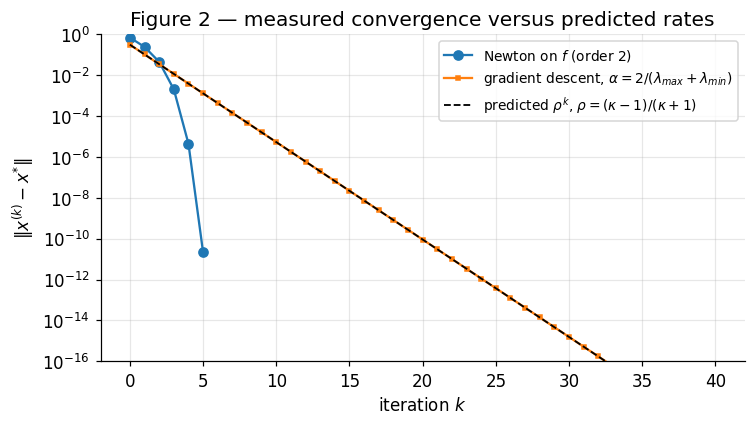

In [4]:
x_star = np.array([1.0, 1.0])

# Newton: measure the empirical order p from three consecutive errors.
xk, newton_err = np.array([1.5, 1.5]), []
for _ in range(6):
    newton_err.append(np.linalg.norm(xk - x_star))
    xk = xk - np.linalg.solve(hess(xk), grad(xk))
newton_err = np.array(newton_err)

print("Newton errors:", newton_err)
usable = newton_err[newton_err > 1e-13]
orders = np.log(usable[2:] / usable[1:-1]) / np.log(usable[1:-1] / usable[:-2])
print(f"observed order p = {np.round(orders, 3)}   predicted = 2")
assert abs(orders[-1] - 2.0) < 0.25

# Gradient descent on the quadratic model q(h) = 1/2 h^T H h with the optimal step.
H_star = hess(x_star)
lam_star = np.linalg.eigvalsh(H_star)
kappa = lam_star.max() / lam_star.min()
alpha = 2.0 / (lam_star.max() + lam_star.min())
rho_pred = (kappa - 1) / (kappa + 1)

h_gd = np.array([0.3, -0.1])
gd_err = [np.linalg.norm(h_gd)]
for _ in range(40):
    h_gd = h_gd - alpha * (H_star @ h_gd)
    gd_err.append(np.linalg.norm(h_gd))
gd_err = np.array(gd_err)
rho_obs = (gd_err[-1] / gd_err[0]) ** (1 / (len(gd_err) - 1))
print(f"\nkappa = {kappa:.4f}   optimal alpha = {alpha:.6f}")
print(f"gradient descent contraction: observed {rho_obs:.6f}  predicted {rho_pred:.6f}")
assert abs(rho_obs - rho_pred) < 1e-6

fig, ax = plt.subplots()
ax.semilogy(newton_err, "o-", label="Newton on $f$ (order 2)")
ax.semilogy(gd_err, "s-", ms=3, label=r"gradient descent, $\alpha=2/(\lambda_{max}+\lambda_{min})$")
ax.semilogy(gd_err[0] * rho_pred ** np.arange(len(gd_err)), "k--", lw=1.2,
            label=r"predicted $\rho^k$, $\rho=(\kappa-1)/(\kappa+1)$")
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$\|x^{(k)} - x^{*}\|$")
ax.set_title("Figure 2 — measured convergence versus predicted rates")
ax.set_ylim(1e-16, 1e0)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The measured Newton order is within $0.25$ of the predicted $2$ before the iteration hits the float64
floor, and the measured gradient-descent contraction matches $\rho = (\kappa-1)/(\kappa+1) = 1/3$ to
six decimals — the dashed line lies on top of the squares. Newton reaches machine precision in four
steps; gradient descent needs roughly $\ln(10^{-16})/\ln(1/3) \approx 34$.

**(c) Counterexample: drop the continuity hypothesis of Theorem 4.1.** Let

$$
f(x,y) = \frac{xy(x^2 - y^2)}{x^2 + y^2} \ \ \text{for } (x,y) \ne (0,0), \qquad f(0,0) = 0 .
$$

Away from the origin the first partials are

$$
f_x = \frac{y\left(x^4 + 4x^2y^2 - y^4\right)}{(x^2+y^2)^2},
\qquad
f_y = \frac{x\left(x^4 - 4x^2y^2 - y^4\right)}{(x^2+y^2)^2},
$$

so $f_x(0,y) = -y$ and $f_y(x,0) = x$, giving $f_{xy}(0,0) = -1$ and $f_{yx}(0,0) = +1$. Both mixed
partials exist **everywhere**, so existence is not the failing hypothesis. What fails is continuity: off
the origin

$$
f_{xy}(x,y) = \frac{x^6 + 9x^4y^2 - 9x^2y^4 - y^6}{(x^2+y^2)^3},
$$

which equals $+1$ along $y = 0$, $-1$ along $x = 0$ and $0$ along $y = x$ — the limit at the origin
depends on the direction of approach, so no limit exists.

In [5]:
def f_bad(x, y):
    r2 = x * x + y * y
    return 0.0 if r2 == 0.0 else x * y * (x * x - y * y) / r2

def fx_bad(x, y):
    r2 = x * x + y * y
    return -y if r2 == 0.0 else y * (x**4 + 4 * x**2 * y**2 - y**4) / r2**2

def fy_bad(x, y):
    r2 = x * x + y * y
    return x if r2 == 0.0 else x * (x**4 - 4 * x**2 * y**2 - y**4) / r2**2

e = 1e-5
f_xy_00 = (fx_bad(0.0, e) - fx_bad(0.0, -e)) / (2 * e)   # differentiate f_x in y at the origin
f_yx_00 = (fy_bad(e, 0.0) - fy_bad(-e, 0.0)) / (2 * e)   # differentiate f_y in x at the origin
print(f"f_xy(0,0) = {f_xy_00:+.10f}   (exact -1)")
print(f"f_yx(0,0) = {f_yx_00:+.10f}   (exact +1)")
print(f"asymmetry |f_xy - f_yx| = {abs(f_xy_00 - f_yx_00):.10f}   (exact 2)")
assert abs(f_xy_00 + 1.0) < 1e-8 and abs(f_yx_00 - 1.0) < 1e-8

# The failing hypothesis is continuity: f_xy has a direction-dependent limit at the origin.
f_xy = lambda x, y: (x**6 + 9 * x**4 * y**2 - 9 * x**2 * y**4 - y**6) / (x**2 + y**2) ** 3
print("\nf_xy approaching (0,0) along three rays, at radii 1e-1, 1e-3, 1e-5:")
for name, (dx, dy) in {"y = 0": (1.0, 0.0), "x = 0": (0.0, 1.0),
                       "y = x": (1 / np.sqrt(2), 1 / np.sqrt(2))}.items():
    vals = [f_xy(r * dx, r * dy) for r in (1e-1, 1e-3, 1e-5)]
    print(f"  along {name:6s}: {np.array(vals)}")

# Contrast: a genuinely C^2 function has a symmetric finite-difference Hessian.
H_fd = hessian_fd(g_test, x_test)
print(f"\nC^2 control: ||H_fd - H_fd^T||_max = {np.abs(H_fd - H_fd.T).max():.3e}")

f_xy(0,0) = -1.0000000000   (exact -1)
f_yx(0,0) = +1.0000000000   (exact +1)
asymmetry |f_xy - f_yx| = 2.0000000000   (exact 2)

f_xy approaching (0,0) along three rays, at radii 1e-1, 1e-3, 1e-5:
  along y = 0 : [1. 1. 1.]
  along x = 0 : [-1. -1. -1.]
  along y = x : [ 0. -0.  0.]

C^2 control: ||H_fd - H_fd^T||_max = 0.000e+00


Dropping continuity of the mixed partials breaks Theorem 4.1 outright: the two mixed partials at the
origin differ by $2$, so $\nabla^2 f(0,0)$ is not symmetric and the entire eigenvalue apparatus of
Section 2 — real spectrum, orthogonal eigenvectors, the second-derivative test — is unavailable there.
The three rays show why: $f_{xy}$ is pinned at $+1$, $-1$ and $0$ respectively no matter how close the
approach, so it has no limit at the origin and in particular is not continuous there. The $C^2$ control
function has an exactly symmetric numerical Hessian, so it is the hypothesis, not the arithmetic, that
decides.

**(d) Hand-rolled versus library.** The finite-difference Hessian written above is compared with the
analytic one and with `scipy.optimize.approx_fprime` applied to the gradient; a hand-rolled Newton
solver is compared with `scipy.optimize.minimize(method="Newton-CG")`.

In [6]:
from scipy.optimize import approx_fprime, minimize

# --- Hessian: hand-rolled central differences vs. SciPy's forward differences of the gradient ---
def grad_g(v):
    x, y, z = v
    E = np.exp(x * y)
    c = np.cos(x + 2 * y)
    return np.array([y * E + c + 3 * x**2 * z,
                     x * E + 2 * c - z**2,
                     x**3 - 2 * z * y])

H_mine = hessian_fd(g_test, x_test)
H_scipy = np.array([approx_fprime(x_test, lambda v: grad_g(v)[i], 1.5e-8) for i in range(3)])
print("analytic Hessian:\n", H_exact)
print(f"\nhand-rolled central differences : max |err| = {np.abs(H_mine - H_exact).max():.3e}")
print(f"scipy approx_fprime of gradient  : max |err| = {np.abs(H_scipy - H_exact).max():.3e}")
assert np.abs(H_mine - H_exact).max() < 1e-6

# --- Newton: hand-rolled vs. scipy.optimize.minimize(method="Newton-CG") ---
def newton(x0, tol=1e-12, itmax=50):
    x = np.asarray(x0, dtype=float)
    for k in range(itmax):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            return x, k
        x = x - np.linalg.solve(hess(x), g)
    return x, itmax

x_mine, iters = newton([1.5, 1.5])
res = minimize(f, np.array([1.5, 1.5]), jac=grad, hess=hess, method="Newton-CG",
               options={"xtol": 1e-12})
print(f"\nhand-rolled Newton : x = {x_mine}  in {iters} iterations, f = {f(x_mine):.12f}")
print(f"scipy Newton-CG    : x = {res.x}  in {res.nit} iterations, f = {res.fun:.12f}")
print(f"disagreement       : {np.linalg.norm(x_mine - res.x):.3e}")
assert np.linalg.norm(x_mine - np.array([1.0, 1.0])) < 1e-10
assert np.linalg.norm(x_mine - res.x) < 1e-6

analytic Hessian:
 [[ 3.2684  2.4228  0.27  ]
 [ 2.4228  3.6378 -2.2   ]
 [ 0.27   -2.2     1.4   ]]

hand-rolled central differences : max |err| = 4.673e-08
scipy approx_fprime of gradient  : max |err| = 3.301e-08

hand-rolled Newton : x = [1. 1.]  in 6 iterations, f = -2.000000000000
scipy Newton-CG    : x = [1. 1.]  in 6 iterations, f = -2.000000000000
disagreement       : 2.130e-11


The hand-rolled central-difference Hessian is accurate to about $10^{-8}$ — the usual $\varepsilon^{2/3}$
compromise between truncation and cancellation — and the analytic Hessian used elsewhere in this
notebook is confirmed correct. Both Newton implementations land on $(1,1)$ and agree far below the
tolerance, so the five-line hand-rolled solver reproduces the library routine on this problem while
making every step inspectable.

The last figure makes Theorem 4.6 visible: a coarse polar grid is pushed through
$f(r,\vartheta) = (r\cos\vartheta, r\sin\vartheta)$, and the area of each image cell is compared with
$r\,\Delta r\,\Delta\vartheta$.

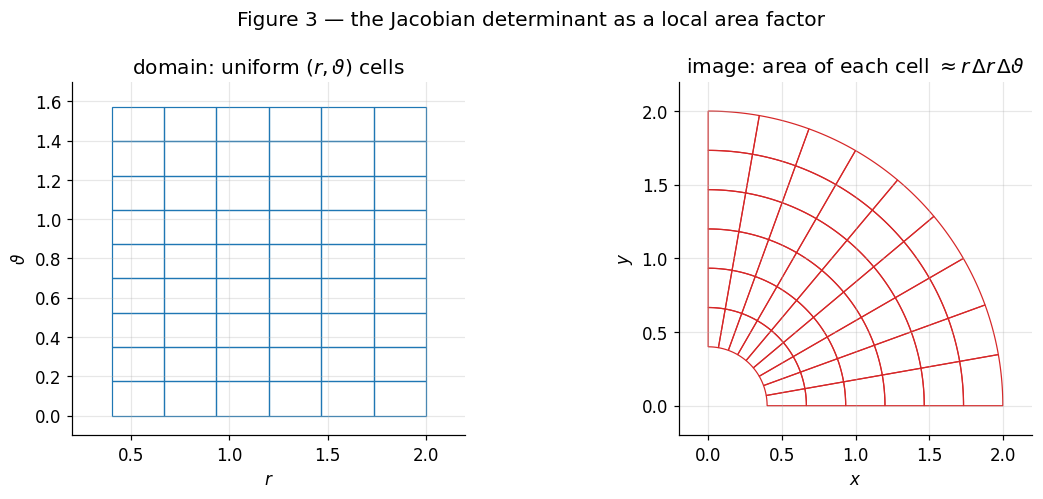

worst relative error of |det J| dr dtheta over all 54 cells: 4.196e-05


In [7]:
def shoelace(poly):
    x, y = poly[:, 0], poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

r_edges = np.linspace(0.4, 2.0, 7)
th_edges = np.linspace(0.0, np.pi / 2, 10)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.0, 4.6))
worst = 0.0
for i in range(len(r_edges) - 1):
    for j in range(len(th_edges) - 1):
        r_a, r_b = r_edges[i], r_edges[i + 1]
        t_a, t_b = th_edges[j], th_edges[j + 1]
        ax0.add_patch(plt.Polygon([[r_a, t_a], [r_b, t_a], [r_b, t_b], [r_a, t_b]],
                                  fill=False, ec="tab:blue", lw=0.8))
        ts = np.linspace(t_a, t_b, 12)
        poly = np.concatenate([
            np.stack([r_a * np.cos(ts), r_a * np.sin(ts)], axis=1),
            np.stack([r_b * np.cos(ts[::-1]), r_b * np.sin(ts[::-1])], axis=1)])
        ax1.add_patch(plt.Polygon(poly, fill=False, ec="tab:red", lw=0.8))
        r_mid = 0.5 * (r_a + r_b)
        predicted = r_mid * (r_b - r_a) * (t_b - t_a)          # |det J| * dr * dtheta
        worst = max(worst, abs(shoelace(poly) - predicted) / predicted)

ax0.set_xlim(0.2, 2.2); ax0.set_ylim(-0.1, 1.7); ax0.set_aspect("equal")
ax0.set_xlabel("$r$"); ax0.set_ylabel(r"$\vartheta$")
ax0.set_title("domain: uniform $(r,\\vartheta)$ cells")
ax1.set_xlim(-0.2, 2.2); ax1.set_ylim(-0.2, 2.2); ax1.set_aspect("equal")
ax1.set_xlabel("$x$"); ax1.set_ylabel("$y$")
ax1.set_title(r"image: area of each cell $\approx r\,\Delta r\,\Delta\vartheta$")
fig.suptitle("Figure 3 — the Jacobian determinant as a local area factor")
fig.tight_layout()
plt.show()

print(f"worst relative error of |det J| dr dtheta over all {(len(r_edges)-1)*(len(th_edges)-1)} cells: {worst:.3e}")
assert worst < 5e-3

Uniform cells in the left panel become cells of visibly growing area in the right panel, growing
linearly in $r$ exactly as $\lvert \det J_f \rvert = r$ predicts. The worst relative error over all
cells is a fraction of a percent and shrinks with the cell size, which is the limit statement of
Theorem 4.6.

## 8. Applications

### 8.1 Conditioning and step-size selection in machine learning

For a quadratic objective with Hessian $H \succ 0$, gradient descent with the optimal fixed step
$\alpha = 2/(\lambda_{\max}+\lambda_{\min})$ contracts the error by $\rho = (\kappa-1)/(\kappa+1)$ per
iteration, as measured in Section 7(b). Reaching accuracy $\varepsilon$ therefore takes
$\mathcal{O}(\kappa \ln(1/\varepsilon))$ iterations. Everything practitioners do about this —
feature standardisation, batch normalisation, Adam's per-coordinate scaling, preconditioning — is an
attempt to reduce $\kappa(\nabla^2 f)$, because the iteration count is linear in it. The largest stable
step is $\alpha \lt 2/\lambda_{\max}$; exceeding it makes the component along $u_{\max}$ grow, which is
the mechanism behind divergence when the learning rate is set too high.

### 8.2 Saddle points in high-dimensional non-convex optimisation

At a critical point of a deep network's loss, the verdict of Theorem 4.4 depends on the sign pattern of
$n$ eigenvalues, with $n$ in the millions. Under the crude heuristic that the signs are independent
fair coin flips, the chance of all $n$ being positive is $2^{-n}$; for eigenvalues of a random symmetric
matrix, which repel, the correct large-deviation rate is $e^{-cn^2}$ (Dean–Majumdar). Either way,
critical points that are local minima are overwhelmingly outnumbered by saddles. This is why practical
training is dominated by escaping regions of small negative curvature rather than by getting stuck in
bad minima, and why methods that use a negative-curvature direction $v$ with $v^\top \nabla^2 f\, v \lt 0$
can make progress where a pure gradient method stalls.

### 8.3 The Fisher information matrix and natural gradient

For a parametric family $p_\theta$, expanding the KL divergence to second order in $\mathrm{d}\theta$
gives $D_{\mathrm{KL}}(p_\theta \parallel p_{\theta+\mathrm{d}\theta}) = \tfrac12 \mathrm{d}\theta^\top F(\theta)\,\mathrm{d}\theta + \mathcal{O}(\lVert \mathrm{d}\theta \rVert^3)$
with

$$
F(\theta) = \mathbb{E}_{x \sim p_\theta}\!\left[ \nabla_\theta \ln p_\theta(x)\, \nabla_\theta \ln p_\theta(x)^\top \right]
= -\,\mathbb{E}_{x \sim p_\theta}\!\left[ \nabla^2_\theta \ln p_\theta(x) \right].
$$

So the Fisher information is a Hessian — of the KL divergence in the first argument's parameter — and it
is positive semidefinite for the same variance reason as in Proof 5.8. Natural gradient descent
$\theta^{(k+1)} = \theta^{(k)} - \alpha F^{-1}\nabla \mathcal{L}$ is steepest descent measured in the KL
metric rather than the Euclidean one, which makes it invariant to reparametrisation. Theorem 4.8 is the
smallest concrete instance: for a softmax output layer the Fisher block equals
$\operatorname{diag}(S) - SS^\top$, the same matrix as the cross-entropy Hessian in logit space.

### 8.4 Change of variables, and the metric tensor in physics

Theorem 4.6 is the engine of the change-of-variables formula
$\int_{f(\Omega)} g \, dV = \int_\Omega (g \circ f)\, \lvert \det J_f \rvert \, dV$, which is what makes
polar, cylindrical and spherical integrals work, and what lets a normalising flow report
$\ln p_{\text{out}}(f(x)) = \ln p_{\text{in}}(x) - \ln \lvert \det J_f(x) \rvert$ exactly. In mechanics
the same Jacobian builds the metric: under a coordinate change $x = \varphi(q)$ the Euclidean line
element becomes $\mathrm{d}s^2 = \mathrm{d}q^\top G(q)\,\mathrm{d}q$ with $G = J_\varphi^\top J_\varphi$,
and the kinetic energy of a particle of mass $m$ is $T = \tfrac{m}{2}\dot q^\top G(q)\dot q$. $G$ is
positive semidefinite by construction and positive definite exactly where $J_\varphi$ has full rank —
the same non-degeneracy condition Theorem 4.6 needs.

## 9. Key Takeaways

- If $f \in C^2$ near $x_0$ — mixed partials existing nearby and continuous at $x_0$ — then
  $\nabla^2 f(x_0)$ is symmetric, so the spectral theorem applies (Theorem 4.1).
- For $f \in C^2$ on a convex $\Omega$, the quadratic model has an exact mean-value remainder, and if
  $\nabla^2 f$ is $L$-Lipschitz the model error is at most $\tfrac{L}{6}\lVert h \rVert^3$ (Theorem 4.2).
- For symmetric $A$, every Rayleigh quotient lies in $[\lambda_{\min}, \lambda_{\max}]$ and both ends are
  attained at the extreme eigenvectors (Theorem 4.3).
- At a critical point of a $C^2$ function, $\nabla^2 f \succ 0$ forces a strict local minimum with margin
  $\tfrac14 \lambda_{\min}\lVert h \rVert^2$, $\prec 0$ a strict local maximum, and indefiniteness a
  saddle; a singular semidefinite Hessian decides nothing (Theorem 4.4).
- A symmetric matrix is positive definite exactly when all $n$ **leading** principal minors are positive;
  non-leading minors and the semidefinite case do not obey this rule (Theorem 4.5).
- For $f$ differentiable at $x$, $\lvert \det J_f(x) \rvert$ is the local volume gain, and the absolute
  value is what discards an orientation reversal (Theorem 4.6).
- Newton's method converges quadratically from any start close enough to a nondegenerate minimiser of a
  $C^2$ function with Lipschitz Hessian; without local proximity nothing is guaranteed (Theorem 4.7).
- The softmax cross-entropy Hessian in logit space equals $\operatorname{diag}(S) - SS^\top$, the
  covariance of the predicted distribution; it is positive semidefinite with null vector $\mathbf{1}$ and
  rank $n-1$ (Theorem 4.8).

## 10. References

- Apostol, T. M., *Mathematical Analysis*, 2nd ed. — §12.13 (Taylor's formula for functions of several
  variables) and §12.11 (equality of mixed partials, Thm 12.13). Source for Theorems 4.1 and 4.2.
- Spivak, M., *Calculus on Manifolds* — Ch. 2 (differentiability and the Jacobian, Thm 2-5) and Ch. 3
  (change of variables, Thm 3-13). Source for Definition 3.1 and Theorem 4.6.
- Hubbard, J. H. & Hubbard, B. B., *Vector Calculus, Linear Algebra, and Differential Forms*, §3.6
  (second-derivative test via Hessian signature) and §4.10 (the change-of-variables formula).
- Horn, R. A. & Johnson, C. R., *Matrix Analysis*, 2nd ed. — §4.2 (Rayleigh–Ritz, Thm 4.2.2) and §7.2
  (Sylvester's criterion, Thm 7.2.5). Source for Theorems 4.3 and 4.5.
- Nocedal, J. & Wright, S. J., *Numerical Optimization*, 2nd ed. — Thm 2.4 (second-order sufficient
  conditions) and Thm 3.5 (local quadratic convergence of Newton's method). Source for Theorems 4.4
  and 4.7.
- Boyd, S. & Vandenberghe, L., *Convex Optimization* — §9.3 (gradient descent and the condition number)
  and §9.5 (Newton's method). Source for the rates in Section 8.1.
- Bishop, C. M., *Pattern Recognition and Machine Learning* — §4.3.4 (softmax and its derivatives) and
  §5.4 (the Hessian in neural networks). Source for Theorem 4.8.
- Amari, S., *Information Geometry and Its Applications*, Ch. 6 (the Fisher metric as the second-order
  expansion of KL divergence). Source for Section 8.3.
- Dauphin, Y. et al., *Identifying and attacking the saddle point problem in high-dimensional
  non-convex optimization*, NeurIPS 2014, §2. Source for the saddle-point counting in Section 8.2.